# Validation 06: DSPS + Cue spectrum fitting

This notebook replaces the old analytic smoke test with the real experimental pipeline:

1. delayed SFH on a redshift-aware cosmic-time grid;
2. continuum-only DSPS/FSPS SSP table for the stellar CSP;
3. Cue public emulator for nebular continuum and lines;
4. modified starburst dust attenuation;
5. Madau IGM;
6. observed-frame spectral likelihood with an explicit resolution/binning step.

The generated mock and the fitter intentionally use the same model. This is a self-consistency validation of data flow, units, masks, and NUTS plumbing, not a cross-model science claim.

In [1]:
OUTPUT_NAME = 'validation_06_dsps_cue_spectrum_fitting'
DEFAULT_WARMUP = '60'
DEFAULT_SAMPLES = '80'

from pathlib import Path
import os
import time
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='Trying to unpickle estimator.*')

# Keep the notebook runnable from either the repository root or notebooks/validation.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'sedinfer').exists():
    REPO_ROOT = Path.cwd().parents[1]

OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / OUTPUT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Real pipeline resources. The SSP file must be continuum-only; Cue adds nebular emission.
SSP_FILE = Path(os.environ.get(
    'DSPS_CONTINUUM_SSP_FILE',
    REPO_ROOT / 'outputs' / 'experimental_dsps_fsps_clock_diagnostic' / 'fsps_continuum_ssp_data.h5',
))
CUE_DATA_DIR = Path(os.environ.get('CUE_DATA_DIR', '/private/tmp/cue/src/cue/data'))

RUN_NUTS = os.environ.get('SEDINFER_VALIDATE_RUN_NUTS', '1') == '1'
NUM_WARMUP = int(os.environ.get('SEDINFER_VALIDATE_NUM_WARMUP', DEFAULT_WARMUP))
NUM_SAMPLES = int(os.environ.get('SEDINFER_VALIDATE_NUM_SAMPLES', DEFAULT_SAMPLES))
RNG_SEED = int(os.environ.get('SEDINFER_VALIDATE_SEED', '8128'))

print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('SSP file:', SSP_FILE)
print('Cue data dir:', CUE_DATA_DIR)
INIT_NUM_CANDIDATES = int(os.environ.get('SEDINFER_VALIDATE_INIT_NUM_CANDIDATES', '512'))
INIT_NUM_STARTS = int(os.environ.get('SEDINFER_VALIDATE_INIT_NUM_STARTS', '8'))
INIT_OPTIMIZER_STEPS = int(os.environ.get('SEDINFER_VALIDATE_INIT_OPTIMIZER_STEPS', '120'))
INIT_LEARNING_RATE = float(os.environ.get('SEDINFER_VALIDATE_INIT_LEARNING_RATE', '0.03'))

print('Run NUTS:', RUN_NUTS, 'warmup:', NUM_WARMUP, 'samples:', NUM_SAMPLES)
print(
    'QMC+Nadam init:',
    'candidates=', INIT_NUM_CANDIDATES,
    'starts=', INIT_NUM_STARTS,
    'steps=', INIT_OPTIMIZER_STEPS,
    'learning_rate=', INIT_LEARNING_RATE,
)

missing = []
if not SSP_FILE.exists():
    missing.append(f'Missing continuum-only DSPS SSP file: {SSP_FILE}')
if not CUE_DATA_DIR.exists():
    missing.append(f'Missing Cue data directory: {CUE_DATA_DIR}')
if missing:
    raise FileNotFoundError('\n'.join(missing))


Repository: /Users/gregoire/Documents/Sedfitting/sedinfer-public
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/validation_06_dsps_cue_spectrum_fitting
SSP file: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/experimental_dsps_fsps_clock_diagnostic/fsps_continuum_ssp_data.h5
Cue data dir: /private/tmp/cue/src/cue/data
Run NUTS: True warmup: 50 samples: 500
QMC+Nadam init: candidates= 512 starts= 8 steps= 120 learning_rate= 0.03


In [2]:

from dsps import load_ssp_templates

from sedinfer.experimental.jaxcigale import (
    CueJaxPort,
    GaussianPhotometricData,
    GaussianSpectralData,
    GaussianSpectroPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    build_jax_sed_model,
    cue_nebular_module,
    delayed_sfh_cosmic_time_module,
    dsps_stellar_module,
    madau_igm_module,
    modified_starburst_attenuation_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    require_continuum_ssp_path,
    run_numpyro_nuts,
)
from sedinfer.experimental.jaxcigale.core import flat_lcdm_age_gyr_numpy
from sedinfer.experimental.jaxcigale.dependencies import require_jax
from sedinfer.experimental.jaxcigale.spectroscopy import model_spectrum_on_observed_pixels

jax, jnp = require_jax()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())
print('JAX scalar dtype:', np.asarray(jnp.asarray(1.0)).dtype)

ssp_data = load_ssp_templates(fn=str(require_continuum_ssp_path(SSP_FILE)))
cue_port = CueJaxPort.from_public_cue_data_dir(CUE_DATA_DIR)
cue_apply = cue_port.make_nebular_apply(line_sigma_a=1.5)
print('Loaded continuum-only SSP and Cue emulator data.')


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX scalar dtype: float64


Loaded continuum-only SSP and Cue emulator data.


In [3]:

def gaussian_filter_set(filter_specs, n_wave=192):
    """Create simple transparent filters for validation.

    Wavelengths are observed-frame Angstrom. These are not official survey
    curves; they are smooth broadbands used only to exercise the integration.
    """
    names, waves, trans = [], [], []
    for name, center_a, sigma_a in filter_specs:
        w = np.linspace(center_a - 4.0 * sigma_a, center_a + 4.0 * sigma_a, n_wave)
        t = np.exp(-0.5 * ((w - center_a) / sigma_a) ** 2)
        names.append(name)
        waves.append(w)
        trans.append(t)
    return JaxFilterSet.from_curves(names, waves, trans)


def make_dsps_cue_model(rest_wave_a, filters, parameter_space, n_sfh_time=96):
    """Build the real validation model: SFH -> DSPS -> Cue -> dust -> IGM -> redshift."""
    fixed_parameters = {
        'E_BV_old_factor': 0.5,
        'powerlaw_slope': 0.0,
        'uv_bump_amplitude': 0.0,
        'E_BV_nebular': 0.12,
        'gas_logn_h': 2.0,
        'gas_logno': -0.134,
        'gas_logco': -0.134,
        'gas_f_esc': 0.0,
        'gas_f_dust': 0.0,
    }
    modules = [
        delayed_sfh_cosmic_time_module(
            n_time=n_sfh_time,
            min_age_since_onset_gyr=0.02,
            tage_parameter='tage_fraction',
            tage_is_fraction_of_universe_age=True,
        ),
        dsps_stellar_module(ssp_data, z_sun=0.02, separation_age_myr=10.0),
        cue_nebular_module(cue_apply),
        modified_starburst_attenuation_module(
            ebv_young_parameter='E_BV_young',
            ebv_old_factor_parameter='E_BV_old_factor',
            powerlaw_slope_parameter='powerlaw_slope',
            uv_bump_amplitude_parameter='uv_bump_amplitude',
            nebular_ebv_parameter='E_BV_nebular',
            nebular_extinction_law='mw_ccm89',
            nebular_rv=3.1,
        ),
        madau_igm_module(),
        redshift_module(),
    ]
    model = build_jax_sed_model(
        modules,
        rest_wave_a,
        filters,
        parameter_space,
        fixed_parameters=fixed_parameters,
    )
    return model, fixed_parameters


def run_short_nuts(model, data, initial_theta):
    """Run a short validation chain. This checks the pipeline, not final science convergence."""
    start = time.perf_counter()
    result = run_numpyro_nuts(
        model,
        data,
        initial_theta=initial_theta,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        rng_seed=RNG_SEED,
        progress_bar=True,
        transform_bounds=True,
        target_accept_prob=0.82,
        max_tree_depth=9,
        dense_mass=False,
        init_strategy='qmc_nadam',
        init_num_candidates=INIT_NUM_CANDIDATES,
        init_num_starts=INIT_NUM_STARTS,
        init_optimizer_steps=INIT_OPTIMIZER_STEPS,
        init_learning_rate=INIT_LEARNING_RATE,
        init_batch_size=min(512, INIT_NUM_CANDIDATES),
    )
    elapsed = time.perf_counter() - start
    print(f'NUTS elapsed: {elapsed:.1f} s; samples/sec: {NUM_SAMPLES / max(elapsed, 1e-12):.3f}')
    return result, elapsed


def posterior_summary(samples, theta_names, truth):
    rows = []
    for i, name in enumerate(theta_names):
        q16, q50, q84 = np.quantile(samples[:, i], [0.16, 0.50, 0.84])
        rows.append({
            'name': name,
            'truth': float(truth[i]),
            'q16': float(q16),
            'median': float(q50),
            'q84': float(q84),
            'median_minus_truth': float(q50 - truth[i]),
        })
    return rows


def save_summary(path, rows, extra):
    payload = {'posterior_summary': rows, **extra}
    path.write_text(json.dumps(payload, indent=2) + '\n')
    print('Saved summary:', path)


def plot_corner_like(samples, theta_names, truth, title):
    n = samples.shape[1]
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.4), constrained_layout=True)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.hist(samples[:, i], bins=24, histtype='stepfilled', alpha=0.65)
        ax.axvline(truth[i], color='k', lw=1.6, label='truth')
        ax.set_title(theta_names[i])
    axes[0].legend(loc='best')
    fig.suptitle(title)
    return fig


## Build a real DSPS + Cue spectral model

Shapes and units:

- rest wavelength grid: Angstrom;
- luminosities in the SED state: `Lsun / Angstrom / formed Msun`;
- observed spectrum: `erg s^-1 cm^-2 Angstrom^-1`;
- mass normalization: `log10_mass` is applied exactly once by `JaxSedModel.run_modules_mass_scaled`.

In [4]:

# The filters are unused by the spectral likelihood, but the model object expects a filter set.
dummy_filters = gaussian_filter_set([('r_like', 6200.0, 550.0)])
rest_wave_a = np.geomspace(60.0, 25000.0, 900)

parameter_space = JaxParameterSpace(
    names=('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh'),
    priors={
        'log10_mass': UniformJaxPrior(7.0, 11.8),
        'z': UniformJaxPrior(0.05, 1.2),
        'logzsol': UniformJaxPrior(-1.5, 0.25),
        'E_BV_young': UniformJaxPrior(0.0, 0.45),
        'tau_gyr': UniformJaxPrior(0.15, 5.0),
        'tage_fraction': UniformJaxPrior(0.08, 0.95),
        'gas_logu': UniformJaxPrior(-3.5, -1.2),
        'gas_logoh': UniformJaxPrior(-1.5, 0.2),
    },
)
model, fixed_parameters = make_dsps_cue_model(rest_wave_a, dummy_filters, parameter_space, n_sfh_time=80)
print('Fitted parameter order:', parameter_space.names)
print('Fixed parameters:', fixed_parameters)


Fitted parameter order: ('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh')
Fixed parameters: {'E_BV_old_factor': 0.5, 'powerlaw_slope': 0.0, 'uv_bump_amplitude': 0.0, 'E_BV_nebular': 0.12, 'gas_logn_h': 2.0, 'gas_logno': -0.134, 'gas_logco': -0.134, 'gas_f_esc': 0.0, 'gas_f_dust': 0.0}


## Simulate one observed spectrum

The mock spectrum is generated from the real model, then convolved/binned through the same spectral response used in the likelihood. The mask removes the noisy edges of the wavelength range.

In [5]:

rng = np.random.default_rng(42)
truth = parameter_space.from_dict({
    'log10_mass': 10.05,
    'z': 0.42,
    'logzsol': -0.35,
    'E_BV_young': 0.12,
    'tau_gyr': 1.8,
    'tage_fraction': 0.48,
    'gas_logu': -2.25,
    'gas_logoh': -0.35,
})
wave_obs_a = np.linspace(3600.0, 9800.0, 180)
pixel_edges = pixel_edges_from_centers_numpy(wave_obs_a)
resolving_power = 700.0

state_truth = model.run_modules_mass_scaled(jnp.asarray(truth))
true_flux = np.asarray(model_spectrum_on_observed_pixels(
    state_truth.wave_obs_a,
    state_truth.flux_lambda_cgs,
    jnp.asarray(wave_obs_a),
    pixel_edges,
    resample_mode='bin',
    resolving_power=resolving_power,
))
sigma = 0.06 * np.maximum(np.abs(true_flux), np.nanmedian(np.abs(true_flux)))
obs_flux = true_flux + rng.normal(0.0, sigma)
mask = (wave_obs_a > 3850.0) & (wave_obs_a < 9550.0)

spectral_data = GaussianSpectralData(
    wavelength_obs_a=wave_obs_a,
    flux_lambda_cgs=obs_flux,
    sigma_lambda_cgs=sigma,
    mask=mask,
    pixel_edges_obs_a=pixel_edges,
    resample_mode='bin',
    resolving_power=resolving_power,
)

print('Spectrum pixels:', wave_obs_a.size, 'active:', int(mask.sum()))
print('Flux unit: erg s^-1 cm^-2 Angstrom^-1')
print('Median S/N:', float(np.median(np.abs(true_flux[mask]) / sigma[mask])))


Spectrum pixels: 180 active: 164
Flux unit: erg s^-1 cm^-2 Angstrom^-1
Median S/N: 16.65644779799858


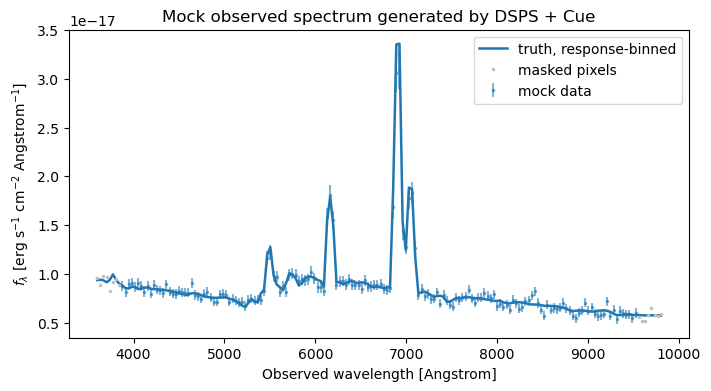

In [6]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wave_obs_a, true_flux, color='tab:blue', lw=1.8, label='truth, response-binned')
ax.errorbar(wave_obs_a[mask], obs_flux[mask], yerr=sigma[mask], fmt='.', ms=3, alpha=0.55, label='mock data')
ax.plot(wave_obs_a[~mask], obs_flux[~mask], '.', color='0.75', ms=3, label='masked pixels')
ax.set_xlabel('Observed wavelength [Angstrom]')
ax.set_ylabel(r'$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]')
ax.set_title('Mock observed spectrum generated by DSPS + Cue')
ax.legend()
fig.savefig(OUTPUT_DIR / 'mock_spectrum.png', dpi=180)
plt.show()


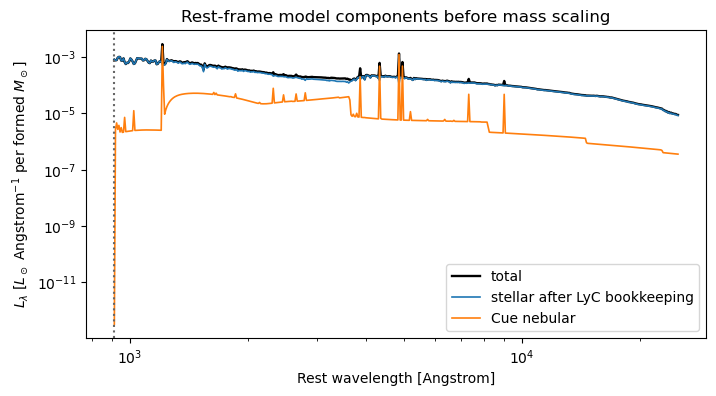

In [7]:

fig, ax = plt.subplots(figsize=(8, 4))
wave_rest = np.asarray(state_truth.wave_rest_a)
stellar = np.asarray(state_truth.stellar_lum_lsun_per_a)
nebular = np.asarray(state_truth.nebular_lum_lsun_per_a)
total = np.asarray(state_truth.total_lum_lsun_per_a)
positive = total > 0
ax.loglog(wave_rest[positive], total[positive], color='k', lw=1.7, label='total')
ax.loglog(wave_rest[stellar > 0], stellar[stellar > 0], color='tab:blue', lw=1.2, label='stellar after LyC bookkeeping')
ax.loglog(wave_rest[nebular > 0], nebular[nebular > 0], color='tab:orange', lw=1.2, label='Cue nebular')
ax.axvline(912.0, ls=':', color='0.4')
ax.set_xlabel('Rest wavelength [Angstrom]')
ax.set_ylabel(r'$L_\lambda$ [$L_\odot$ Angstrom$^{-1}$ per formed $M_\odot$]')
ax.set_title('Rest-frame model components before mass scaling')
ax.legend()
fig.savefig(OUTPUT_DIR / 'rest_components.png', dpi=180)
plt.show()


## Short NUTS validation fit

This chain is deliberately short so the notebook is runnable. Treat it as a pipeline check: did gradients, bounds, masks, units, and posterior prediction all stay connected?

In [8]:

initial_theta = parameter_space.from_dict({
    'log10_mass': 9.9,
    'z': 0.46,
    'logzsol': -0.55,
    'E_BV_young': 0.08,
    'tau_gyr': 2.4,
    'tage_fraction': 0.42,
    'gas_logu': -2.6,
    'gas_logoh': -0.55,
})

if RUN_NUTS:
    result, nuts_elapsed = run_short_nuts(model, spectral_data, initial_theta)
    samples = np.asarray(result.samples)
    rows = posterior_summary(samples, result.theta_names, truth)
    for row in rows:
        print(f"{row['name']:12s} truth={row['truth']: .4f} median={row['median']: .4f} [{row['q16']: .4f}, {row['q84']: .4f}]")
    save_summary(
        OUTPUT_DIR / 'nuts_summary.json',
        rows,
        {'nuts_elapsed_seconds': nuts_elapsed, 'num_warmup': NUM_WARMUP, 'num_samples': NUM_SAMPLES},
    )
    np.savez(OUTPUT_DIR / 'nuts_samples.npz', samples=samples, theta_names=np.asarray(result.theta_names), truth=truth)
else:
    samples = np.empty((0, parameter_space.ndim))
    print('Skipped NUTS because RUN_NUTS is False.')


  0%|          | 0/550 [00:00<?, ?it/s]

warmup:   0%|          | 0/550 [00:10<?, ?it/s, 511 steps of size 8.96e-04. acc. prob=0.19]

warmup:   1%|          | 6/550 [00:12<18:18,  2.02s/it, 511 steps of size 1.19e-03. acc. prob=0.33]

warmup:   1%|▏         | 7/550 [00:16<22:41,  2.51s/it, 511 steps of size 9.81e-05. acc. prob=0.29]

warmup:   1%|▏         | 8/550 [00:21<26:43,  2.96s/it, 511 steps of size 1.54e-04. acc. prob=0.38]

...

sample: 100%|█████████▉| 548/550 [20:06<00:04,  2.17s/it, 319 steps of size 2.39e-02. acc. prob=0.87]

sample: 100%|█████████▉| 549/550 [20:07<00:01,  1.95s/it, 159 steps of size 2.39e-02. acc. prob=0.87]

sample: 100%|██████████| 550/550 [20:12<00:00,  2.77s/it, 511 steps of size 2.39e-02. acc. prob=0.87]

sample: 100%|██████████| 550/550 [20:12<00:00,  2.20s/it, 511 steps of size 2.39e-02. acc. prob=0.87]

NUTS elapsed: 1273.7 s; samples/sec: 0.393
log10_mass   truth= 10.0500 median= 10.1622 [ 10.1221,  10.2002]
z            truth= 0.4200 median= 0.4201 [ 0.4200,  0.4203]
logzsol      truth=-0.3500 median=-0.4496 [-0.6486, -0.2094]
E_BV_young   truth= 0.1200 median= 0.0998 [ 0.0891,  0.1092]
tau_gyr      truth= 1.8000 median= 3.2423 [ 2.5883,  3.7877]
tage_fraction truth= 0.4800 median= 0.7944 [ 0.6656,  0.8887]
gas_logu     truth=-2.2500 median=-1.8978 [-2.2343, -1.4230]
gas_logoh    truth=-0.3500 median=-0.2998 [-0.5491, -0.1468]
Saved summary: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/validation_06_dsps_cue_spectrum_fitting/nuts_summary.json


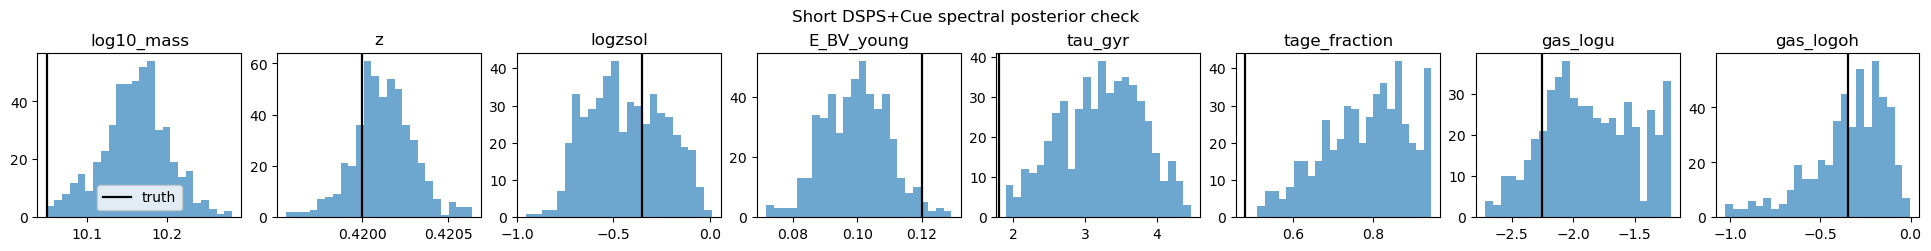

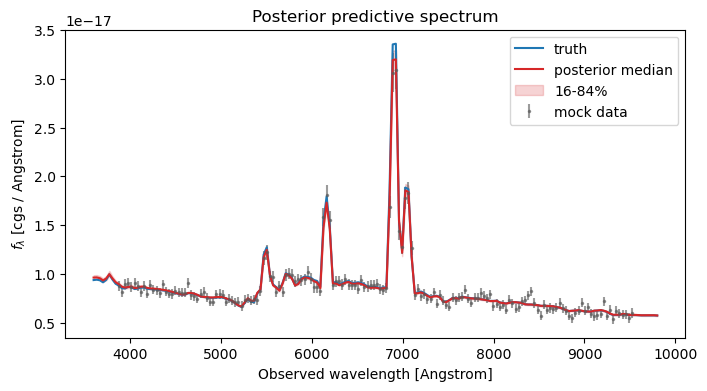

In [9]:

if RUN_NUTS:
    fig = plot_corner_like(samples, result.theta_names, truth, 'Short DSPS+Cue spectral posterior check')
    fig.savefig(OUTPUT_DIR / 'posterior_marginals.png', dpi=180)
    plt.show()

    # Posterior predictive from a small deterministic subset of samples.
    take = np.linspace(0, len(samples) - 1, min(24, len(samples))).astype(int)
    pred = []
    for theta in samples[take]:
        state = model.run_modules_mass_scaled(jnp.asarray(theta))
        f = np.asarray(model_spectrum_on_observed_pixels(
            state.wave_obs_a,
            state.flux_lambda_cgs,
            jnp.asarray(wave_obs_a),
            pixel_edges,
            resample_mode='bin',
            resolving_power=resolving_power,
        ))
        pred.append(f)
    pred = np.asarray(pred)
    med = np.median(pred, axis=0)
    lo, hi = np.quantile(pred, [0.16, 0.84], axis=0)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(wave_obs_a[mask], obs_flux[mask], yerr=sigma[mask], fmt='.', color='0.35', ms=3, alpha=0.6, label='mock data')
    ax.plot(wave_obs_a, true_flux, color='tab:blue', lw=1.5, label='truth')
    ax.plot(wave_obs_a, med, color='tab:red', lw=1.5, label='posterior median')
    ax.fill_between(wave_obs_a, lo, hi, color='tab:red', alpha=0.2, label='16-84%')
    ax.set_xlabel('Observed wavelength [Angstrom]')
    ax.set_ylabel(r'$f_\lambda$ [cgs / Angstrom]')
    ax.set_title('Posterior predictive spectrum')
    ax.legend()
    fig.savefig(OUTPUT_DIR / 'posterior_predictive_spectrum.png', dpi=180)
    plt.show()
